In [1]:
import os

# Additional imports
import cv2
import matplotlib.pyplot as plt
from xml.etree import ElementTree as ET
import numpy as np
import random
import yaml
import shutil
from pathlib import Path


In [2]:
# Function to convert polygon to bounding box
def polygon_to_bbox(polygon):
    """
    Convert a polygon (list of (x,y) points) to a bounding box (x_min, y_min, x_max, y_max)
    """
    points = np.array(polygon)
    x_min, y_min = points.min(axis=0)
    x_max, y_max = points.max(axis=0)
    return x_min, y_min, x_max, y_max

# Function to convert bounding box to YOLO format
def bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bounding box to YOLO format (center_x, center_y, width, height) normalized
    """
    x_min, y_min, x_max, y_max = bbox
    
    # Calculate center coordinates
    center_x = (x_min + x_max) / 2.0
    center_y = (y_min + y_max) / 2.0
    
    # Calculate width and height
    width = x_max - x_min
    height = y_max - y_min
    
    # Normalize by image dimensions
    center_x /= img_width
    center_y /= img_height
    width /= img_width
    height /= img_height
    
    return center_x, center_y, width, height


In [3]:
# Function to parse PAGE XML and extract text line polygons
def parse_page_xml_polygons(xml_path):
    """
    Parse PAGE XML file and extract text line polygons
    Returns list of polygons, each polygon is a list of (x,y) coordinates
    """
    ns = {"ns": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"}
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    polygons = []
    for tl in root.findall(".//ns:TextLine", ns):
        coords = tl.find("ns:Coords", ns)
        if coords is not None:
            # Parse points string into list of (x,y) tuples
            pts = [(int(x), int(y)) for x, y in
                   (p.split(",") for p in coords.attrib["points"].split())]
            polygons.append(pts)
    return polygons

# Function to convert PAGE XML to YOLO labels
def convert_xml_to_yolo(xml_path, img_path, output_label_path):
    """
    Convert PAGE XML annotations to YOLO format labels
    """
    # Get image dimensions
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image {img_path}")
        return False
    
    img_height, img_width = img.shape[:2]
    
    # Parse polygons from XML
    polygons = parse_page_xml_polygons(xml_path)
    
    # Convert polygons to YOLO format
    yolo_labels = []
    for polygon in polygons:
        if len(polygon) >= 3:  # Need at least 3 points for a polygon
            bbox = polygon_to_bbox(polygon)
            yolo_bbox = bbox_to_yolo(bbox, img_width, img_height)
            # YOLO format: class_id center_x center_y width height
            yolo_labels.append(f"0 {yolo_bbox[0]:.6f} {yolo_bbox[1]:.6f} {yolo_bbox[2]:.6f} {yolo_bbox[3]:.6f}")
    
    # Write YOLO labels to file
    with open(output_label_path, 'w') as f:
        f.write('\n'.join(yolo_labels))
    
    return True


In [4]:
# Function to visualize bounding boxes on image
def visualize_bboxes(img_path, xml_path=None, yolo_labels_path=None):
    """
    Visualize bounding boxes on image from either XML or YOLO labels
    """
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not read image {img_path}")
        return
    
    img_display = img.copy()
    img_height, img_width = img.shape[:2]
    
    bboxes = []
    
    if xml_path and os.path.exists(xml_path):
        # Load from XML
        polygons = parse_page_xml_polygons(xml_path)
        for polygon in polygons:
            if len(polygon) >= 3:
                bbox = polygon_to_bbox(polygon)
                bboxes.append(bbox)
    elif yolo_labels_path and os.path.exists(yolo_labels_path):
        # Load from YOLO labels
        with open(yolo_labels_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, center_x, center_y, width, height = map(float, parts)
                    # Convert from normalized YOLO format to pixel coordinates
                    center_x *= img_width
                    center_y *= img_height
                    width *= img_width
                    height *= img_height
                    
                    x_min = center_x - width / 2
                    y_min = center_y - height / 2
                    x_max = center_x + width / 2
                    y_max = center_y + height / 2
                    
                    bboxes.append((x_min, y_min, x_max, y_max))
    
    # Draw bounding boxes
    for bbox in bboxes:
        x_min, y_min, x_max, y_max = map(int, bbox)
        cv2.rectangle(img_display, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    
    # Display image
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Bounding Boxes - {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()


In [5]:
# Function to process a dataset split (train/val/test)
def convert_split(img_dir, xml_dir, out_img_dir, out_label_dir):
    """
    Convert a dataset split from PAGE XML to YOLO format
    """
    # Create output directories
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_label_dir, exist_ok=True)
    
    # Get list of XML files
    xml_files = []
    for ext in ['*.xml']:
        xml_files.extend(Path(xml_dir).glob(ext))
    
    processed_count = 0
    for xml_file in xml_files:
        # Find corresponding image file
        xml_name = xml_file.stem
        img_name = xml_name  # Assume same name
        img_file = None
        
        # Try different image extensions
        for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff']:
            potential_img = Path(img_dir) / f"{img_name}{ext}"
            if potential_img.exists():
                img_file = potential_img
                break
        
        if img_file is None:
            print(f"Warning: No corresponding image found for {xml_file}")
            continue
        
        # Define output paths
        output_img_path = Path(out_img_dir) / img_file.name
        output_label_path = Path(out_label_dir) / f"{xml_name}.txt"
        
        # Copy image to output directory
        shutil.copy2(img_file, output_img_path)
        
        # Convert XML to YOLO labels
        success = convert_xml_to_yolo(str(xml_file), str(img_file), str(output_label_path))
        if success:
            print(f"[OK] {img_file.name} → YOLO label created")
            processed_count += 1
        else:
            print(f"[FAIL] {img_file.name} → Failed to create YOLO label")
    
    print(f"Processed {processed_count} images in {Path(img_dir).name}")


In [6]:
# Function to create YOLO dataset.yaml
def create_yolo_dataset_yaml(dataset_path, output_yaml_path="dataset.yaml"):
    """
    Create YOLO dataset.yaml configuration file
    """
    dataset_path = Path(dataset_path)
    
    # Check if required directories exist
    images_train = dataset_path / "images" / "train"
    images_val = dataset_path / "images" / "val"
    images_test = dataset_path / "images" / "test"
    
    # Define class names (only textline for now)
    names = {
        0: "textline"
    }
    
    # Create dataset configuration
    config = {
        "path": str(dataset_path),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": names
    }
    
    # Write YAML file
    with open(output_yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
    
    print(f"Created YOLO dataset configuration: {output_yaml_path}")


In [7]:
# Function to plot a random image with bounding boxes
def plot_random_image(dataset_path):
    """
    Plot a random image from the dataset with bounding boxes
    """
    dataset_path = Path(dataset_path)
    
    # Get all image files from train/val/test splits
    image_files = []
    for split in ["train", "val", "test"]:
        split_dir = dataset_path / "images" / split
        if split_dir.exists():
            image_files.extend(list(split_dir.glob("*")))
    
    if not image_files:
        print("No images found in dataset")
        return
    
    # Select random image
    random_img = random.choice(image_files)
    
    # Find corresponding label file
    label_file = dataset_path / "labels" / random_img.parent.name / f"{random_img.stem}.txt"
    
    # Visualize
    visualize_bboxes(str(random_img), yolo_labels_path=str(label_file))


In [12]:
# --- Configuration ---
# Define paths for different datasets (configure these as needed)
DATASETS = {
    "CB55": {
        "train_img": "../00_data/DIVA-HisDB/CB55/img-CB55/img/training",
        "train_xml": "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55-TASK-2/TASK-2/training",
        "val_img": "../00_data/DIVA-HisDB/CB55/img-CB55/img/validation",
        "val_xml": "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55-TASK-2/TASK-2/validation",
        "test_img": "../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test",
        "test_xml": "../00_data/DIVA-HisDB/CB55/PAGE-gt-CB55-TASK-2/TASK-2/public-test",
        "output_dir": "../00_data/DIVA-HisDB/yolo_dataset_cb55"
    },
    "CS18": {
        "train_img": "../00_data/DIVA-HisDB/CS18/img-CS18/img/training",
        "train_xml": "../00_data/DIVA-HisDB/CS18/PAGE-gt-CS18-TASK-2/TASK-2/training",
        "val_img": "../00_data/DIVA-HisDB/CS18/img-CS18/img/validation",
        "val_xml": "../00_data/DIVA-HisDB/CS18/PAGE-gt-CS18-TASK-2/TASK-2/validation",
        "test_img": "../00_data/DIVA-HisDB/CS18/img-CS18/img/public-test",
        "test_xml": "../00_data/DIVA-HisDB/CS18/PAGE-gt-CS18-TASK-2/TASK-2/public-test",
        "output_dir": "../00_data/DIVA-HisDB/yolo_dataset_cs18"
    },
    "CS863": {
        "train_img": "../00_data/DIVA-HisDB/CS863/img-CS863/img/training",
        "train_xml": "../00_data/DIVA-HisDB/CS863/PAGE-gt-CS863-TASK-2/TASK-2/training",
        "val_img": "../00_data/DIVA-HisDB/CS863/img-CS863/img/validation",
        "val_xml": "../00_data/DIVA-HisDB/CS863/PAGE-gt-CS863-TASK-2/TASK-2/validation",
        "test_img": "../00_data/DIVA-HisDB/CS863/img-CS863/img/public-test",
        "test_xml": "../00_data/DIVA-HisDB/CS863/PAGE-gt-CS863-TASK-2/TASK-2/public-test",
        "output_dir": "../00_data/DIVA-HisDB/yolo_dataset_cs863"
    }
}

# Select which dataset to process
SELECTED_DATASET = "CS863"  # Change this to "CS18" or "CS863" as needed

# Get configuration for selected dataset
config = DATASETS[SELECTED_DATASET]


Processing CS863 dataset...
[OK] e-codices_csg-0863_153_max.jpg → YOLO label created
[OK] e-codices_csg-0863_257_max.jpg → YOLO label created
[OK] e-codices_csg-0863_010_max.jpg → YOLO label created
[OK] e-codices_csg-0863_262_max.jpg → YOLO label created
[OK] e-codices_csg-0863_241_max.jpg → YOLO label created
[OK] e-codices_csg-0863_250_max.jpg → YOLO label created
[OK] e-codices_csg-0863_261_max.jpg → YOLO label created
[OK] e-codices_csg-0863_260_max.jpg → YOLO label created
[OK] e-codices_csg-0863_252_max.jpg → YOLO label created
[OK] e-codices_csg-0863_155_max.jpg → YOLO label created
[OK] e-codices_csg-0863_263_max.jpg → YOLO label created
[OK] e-codices_csg-0863_009_max.jpg → YOLO label created
[OK] e-codices_csg-0863_154_max.jpg → YOLO label created
[OK] e-codices_csg-0863_265_max.jpg → YOLO label created
[OK] e-codices_csg-0863_212_max.jpg → YOLO label created
[OK] e-codices_csg-0863_184_max.jpg → YOLO label created
[OK] e-codices_csg-0863_012_max.jpg → YOLO label created
[OK

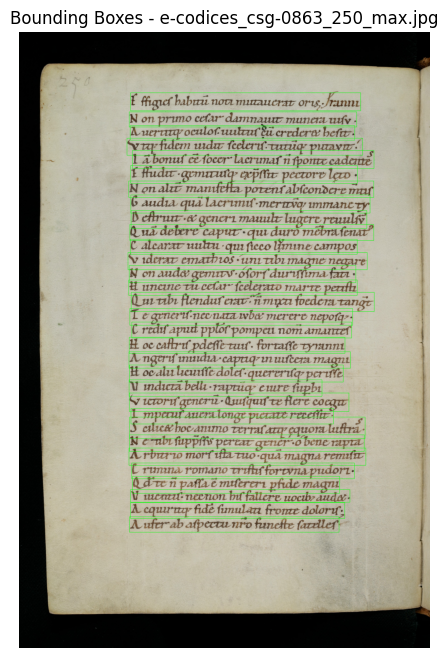

Dataset processing complete! YOLO dataset created at: ../00_data/DIVA-HisDB/yolo_dataset_cs863


In [13]:
# --- Process Dataset ---
print(f"Processing {SELECTED_DATASET} dataset...")

# Process training split
convert_split(
    img_dir=config["train_img"],
    xml_dir=config["train_xml"],
    out_img_dir=f"{config['output_dir']}/images/train",
    out_label_dir=f"{config['output_dir']}/labels/train"
)

# Process validation split
convert_split(
    img_dir=config["val_img"],
    xml_dir=config["val_xml"],
    out_img_dir=f"{config['output_dir']}/images/val",
    out_label_dir=f"{config['output_dir']}/labels/val"
)

# Process test split
convert_split(
    img_dir=config["test_img"],
    xml_dir=config["test_xml"],
    out_img_dir=f"{config['output_dir']}/images/test",
    out_label_dir=f"{config['output_dir']}/labels/test"
)

# Create YOLO dataset.yaml
create_yolo_dataset_yaml(config["output_dir"], f"{config['output_dir']}/dataset.yaml")

# Plot a random image with bounding boxes
print("Plotting a random image with bounding boxes...")
plot_random_image(config["output_dir"])

print(f"Dataset processing complete! YOLO dataset created at: {config['output_dir']}")
